In [1]:
import pandas as pd
import os
import pandas as pd

# Directory containing the folders
base_dir = 'allele_differences_withoutcontrol/20240813_allele_only'
# Initialize an empty DataFrame for the final result
final_df = pd.DataFrame()

# Loop through each folder in the base directory
for file in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file)

        df_ref = pd.read_csv(file_path,index_col=0)[["logFC"]]
        df_ref.columns = [file[21:-15]]

        # Append to the final DataFrame
        final_df = pd.concat([final_df, df_ref],axis=1)

#final_df=final_df.rename({"THP1Monocyte":"THP1 Monocyte","THP1Macrophage":"THP1 Macrophage","BrainR1R2merged20240404":"Brain","HMC3":"HMC3 Microglia", "GutR1R2merged20240404": "Gut"},axis=1)
final_df=final_df.rename({"THP1Monocyte":"THP1 Monocyte","THP1Macrophage":"THP1 Macrophage","BrainR1R2merged20240404":"Brain","HMC3":"HMC3 Microglia", "GutR1R2merged20240404": "Gut","GutR1R2merged20240404_LI": "Large_Intestine",
                          "GutR1R2merged20240404_SI": "Small_Intestine","BrainR1R2merged20240404_Cortex":"Brain_Cortex","BrainR1R2merged20240404_Hippocampus":"Brain_Hippocampus","BrainR1R2merged20240404_Striatum":"Brain_Striatum"},axis=1)

In [12]:
df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_202401021.csv',index_col=0)
final_df = pd.merge(final_df,df_index[['rsid_gene']],left_index=True,right_index=True)

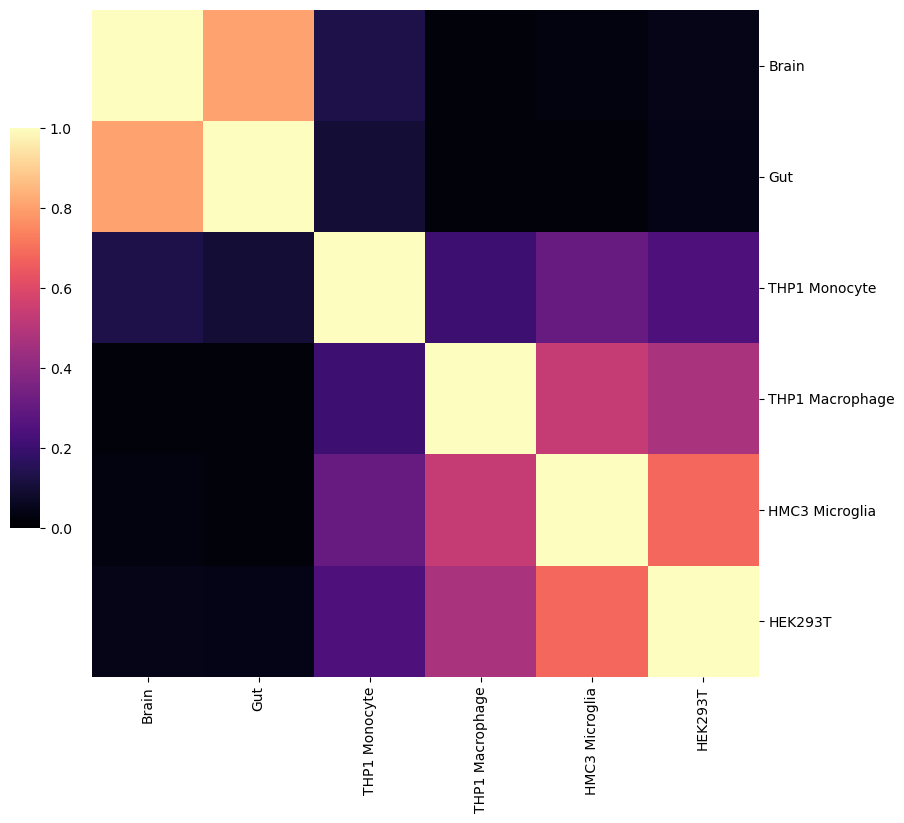

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
cg = sns.clustermap(final_df[['THP1 Monocyte','THP1 Macrophage','Brain','HMC3 Microglia','Gut',"HEK293T"]].corr('spearman'),vmin=0,annot=False,fmt=".2f", cmap='magma')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_position([0.1, 0.3, 0.03, 0.4])  

plt.savefig('allele_differences_logFC_correlation_by_tissue_Heatmap.pdf', format='pdf')

<Figure size 4500x3600 with 0 Axes>

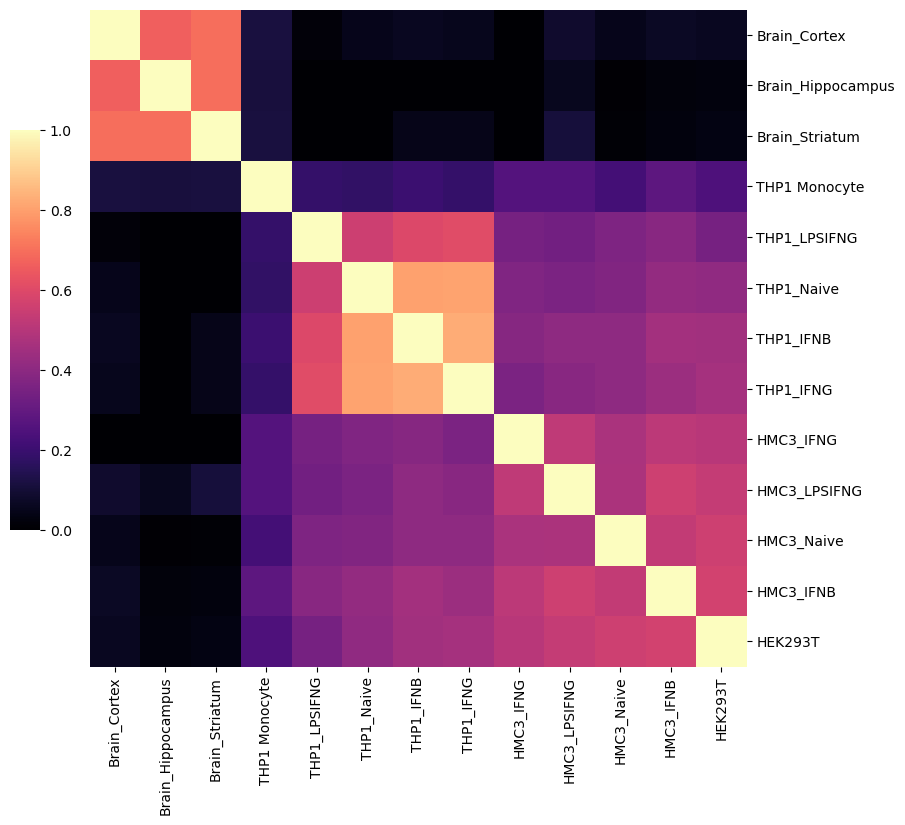

In [43]:
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 12), dpi=300)
cg = sns.clustermap(final_df.drop(['THP1 Macrophage','Brain','HMC3 Microglia','Gut','HMC3THP1mac_CommonEffects','Large_Intestine','Small_Intestine'],axis=1).corr('spearman'),vmin=0,annot=False,fmt=".2f", cmap='magma')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_position([0.1, 0.3, 0.03, 0.4])  
plt.savefig('allele_differences_logFC_correlation_by_celltype_Heatmap.pdf', format='pdf')

In [ ]:
#################need keep#############
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Input files
files = {
    "IFN-β": "annotated_20240616_comparative_THP1_IFNB_alleleOnly.csv",
    "IFN-γ": "annotated_20240616_comparative_THP1_IFNG_alleleOnly.csv",
    "LPS+IFN-γ": "annotated_20240616_comparative_THP1_LPSIFNG_alleleOnly.csv",
    "Naive": "annotated_20240616_comparative_THP1_Naive_alleleOnly.csv",
}

value_col = "logFC_converted"

# Load allele-effect values and align by shared variant/element IDs
series = {}
for label, path in files.items():
    df = pd.read_csv(path, index_col=0)

    s = pd.to_numeric(df[value_col], errors="coerce")
    s = s[~s.index.duplicated(keep="first")]

    series[label] = s

mat = pd.concat(series, axis=1, join="inner").dropna()

# Pearson correlation
corr = mat.corr(method="pearson")

# Save correlation matrix
corr.to_csv("THP1_cross_condition_allelic_effect_correlation_matrix_greek.csv")

# Plot
fig, ax = plt.subplots(figsize=(5.3, 4.55), dpi=300)

im = ax.imshow(
    corr.values,
    vmin=0,
    vmax=1,
    cmap="Blues",
    aspect="equal"
)

labels = list(corr.columns)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(
    labels,
    fontsize=16,
    rotation=35,
    ha="right",
    rotation_mode="anchor"
)
ax.set_yticklabels(labels, fontsize=16)

# Cell gridlines
ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.6)

ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

# Cell annotations
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if val >= 0.78 else "black"
        )

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "THP-1 allelic-effect correlation",
    fontsize=18,
    pad=12
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.042, pad=0.035)
cbar.set_label("Pearson r", fontsize=15)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(
    "THP1_cross_condition_allelic_effect_correlation_heatmap_greek.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()